In [1]:
import pandas as pd

In [2]:
## PAM gene list
import requests

pam50_url = "https://raw.githubusercontent.com/mlist/IB2014/master/pam50.txt"
pam50 = [g.strip() for g in requests.get(pam50_url, timeout=30).text.splitlines() if g.strip()]
print(len(pam50), pam50[:10])

51 ['"x"', '"ACTR3B"', '"ANLN"', '"BAG1"', '"BCL2"', '"BIRC5"', '"BLVRA"', '"CCNB1"', '"CCNE1"', '"CDC20"']


In [3]:
base_folder = "/main/projects/GANomics/dashboard/backend/results_old/2_SyncData/BRCA-1_100_0/test/"
df_ma_real = pd.read_csv(f'{base_folder}/microarray_real.csv',index_col=0)
df_ma_fake = pd.read_csv(f'{base_folder}/microarray_fake.csv',index_col=0)
df_rs_real = pd.read_csv(f'{base_folder}/rnaseq_real.csv',index_col=0)
df_rs_fake = pd.read_csv(f'{base_folder}/rnaseq_fake.csv',index_col=0)

In [4]:
df_raw = pd.read_csv('/main/projects/GANomics/dashboard/backend/dataset/BRCA-1/df_ag.tsv',sep="\t",index_col=0)
df_raw.head(1)

,A1BG,A2BP1,A2ML1,A2M,A4GALT,A4GNT,AAAS,AACS,AADACL2,AADACL3,...,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,PSITPTE22,TAKR
TCGA-E2-A15A-01A-11R-A12D-07,0.5745,-2.238333,-1.5045,0.5985,1.9285,0.359,-0.28475,0.997,-0.806667,0.417,...,-0.227167,1.07,-0.10475,-1.01125,-0.955,0.094167,0.387333,-0.6095,-0.69325,0.024


In [5]:
PAM_col = [(ind, d) for ind, d in enumerate(df_raw.columns) if '"'+d+'"' in pam50]
len(PAM_col)

50

In [6]:
df_ma_real_pam50 = df_ma_real.iloc[:, [x[0] for x in PAM_col]]
df_ma_fake_pam50 = df_ma_fake.iloc[:, [x[0] for x in PAM_col]]
df_rs_real_pam50 = df_rs_real.iloc[:, [x[0] for x in PAM_col]]
df_rs_fake_pam50 = df_rs_fake.iloc[:, [x[0] for x in PAM_col]]

df_ma_real_pam50.columns = [x[1] for x in PAM_col]
df_ma_fake_pam50.columns = [x[1] for x in PAM_col]
df_rs_real_pam50.columns = [x[1] for x in PAM_col]
df_rs_fake_pam50.columns = [x[1] for x in PAM_col]

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression


# ---------- helpers ----------
def align_frames(A, B):
    genes   = A.columns.intersection(B.columns)
    samples = A.index.intersection(B.index)
    A2 = A.loc[samples, genes].sort_index()
    B2 = B.loc[samples, genes].sort_index()
    return A2, B2

def lin_ccc(x, y):
    x = np.asarray(x); y = np.asarray(y)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    sxy = np.cov(x, y, ddof=1)[0, 1]
    denom = vx + vy + (mx - my) ** 2
    return (2 * sxy) / denom if denom != 0 else np.nan

def per_sample_stats(A, B):
    # correlations across genes for each sample
    pear = A.apply(lambda r: pearsonr(r.values, B.loc[r.name].values)[0], axis=1)
    spear = A.apply(lambda r: spearmanr(r.values, B.loc[r.name].values).correlation, axis=1)
    ccc = A.apply(lambda r: lin_ccc(r.values, B.loc[r.name].values), axis=1)
    mae = (A - B).abs().mean(axis=1)
    rmse = np.sqrt(((A - B) ** 2).mean(axis=1))
    return pd.DataFrame({"pearson_r": pear, "spearman_r": spear, "ccc": ccc, "mae": mae, "rmse": rmse})

def per_gene_stats(A, B):
    pear = {g: pearsonr(A[g].values, B[g].values)[0] for g in A.columns}
    spear = {g: spearmanr(A[g].values, B[g].values).correlation for g in A.columns}
    return pd.DataFrame({"pearson_r": pear, "spearman_r": spear}).sort_values("pearson_r", ascending=False)


def genewise_calibration(A, B):
    """A,B are aligned dataframes (samples×genes). Returns gene-level stats."""
    out = []
    for g in A.columns:
        x = A[g].values.reshape(-1,1); y = B[g].values
        lr = LinearRegression().fit(x, y)
        slope = float(lr.coef_[0]); intercept = float(lr.intercept_)
        r_p = pearsonr(A[g], B[g])[0]; r_s = spearmanr(A[g], B[g]).correlation
        mae = np.mean(np.abs(B[g]-A[g])); rmse = np.sqrt(np.mean((B[g]-A[g])**2))
        var_ratio = float(np.var(B[g], ddof=1)/np.var(A[g], ddof=1)) if np.var(A[g], ddof=1)>0 else np.nan
        out.append([g, r_p, r_s, mae, rmse, slope, intercept, var_ratio])
    cols = ["gene","pearson_r","spearman_r","mae","rmse","slope","intercept","var_ratio"]
    return pd.DataFrame(out, columns=cols).set_index("gene").sort_values("mae")

def pooled_stats(A, B):
    X = A.values.ravel(); Y = B.values.ravel()
    return {
        "pearson_r": pearsonr(X, Y)[0],
        "spearman_r": spearmanr(X, Y).correlation,
        "ccc": lin_ccc(X, Y),
        "mae": np.mean(np.abs(X - Y)),
        "rmse": np.sqrt(np.mean((X - Y) ** 2)),
        "n_points": X.size,
        "min_val": float(np.nanmin([X.min(), Y.min()])),
        "max_val": float(np.nanmax([X.max(), Y.max()])),
        "X": X, "Y": Y  # for plotting
    }

def bland_altman(X, Y):
    diff = Y - X
    mean = (Y + X) / 2
    bias = np.mean(diff)
    sd = np.std(diff, ddof=1)
    loa_lo, loa_hi = bias - 1.96 * sd, bias + 1.96 * sd
    return mean, diff, bias, sd, loa_lo, loa_hi


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_pam50_consistency_2x2(
    df_ma_real_pam50, df_ma_fake_pam50,
    df_rs_real_pam50, df_rs_fake_pam50,
    save_path=None,
    overlay_baseline_in_ba=True
):
    sns.set_theme(style="white")
    plt.rcParams.update({
        "font.size": 13,
        "axes.titlesize": 15,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11
    })

    # ---------- align data ----------
    A_ma, B_ma = align_frames(df_ma_real_pam50, df_ma_fake_pam50)
    A_rs, B_rs = align_frames(df_rs_real_pam50, df_rs_fake_pam50)
    A_bl, B_bl = align_frames(df_ma_real_pam50, df_rs_real_pam50)

    if A_ma.empty or A_rs.empty or A_bl.empty:
        raise ValueError("One or more PAM50 comparisons have no overlapping samples/genes.")

    # ---------- compute stats ----------
    ps_ma = per_sample_stats(A_ma, B_ma)
    ps_rs = per_sample_stats(A_rs, B_rs)
    ps_bl = per_sample_stats(A_bl, B_bl)

    pg_ma = genewise_calibration(A_ma, B_ma)
    pg_rs = genewise_calibration(A_rs, B_rs)
    pg_bl = genewise_calibration(A_bl, B_bl)

    gl_rs = pooled_stats(A_rs, B_rs)
    gl_bl = pooled_stats(A_bl, B_bl)

    # ---------- assemble plotting tables ----------
    per_sample_df = pd.DataFrame({
        "Comparison": (["MA real vs syn"] * len(ps_ma) +
                       ["RS real vs syn"] * len(ps_rs) +
                       ["Baseline"] * len(ps_bl)),
        "Pearson r": np.concatenate([
            ps_ma["pearson_r"].values,
            ps_rs["pearson_r"].values,
            ps_bl["pearson_r"].values
        ])
    })

    per_gene_df = pd.DataFrame({
        "Comparison": (["MA real vs syn"] * len(pg_ma) +
                       ["RS real vs syn"] * len(pg_rs) +
                       ["Baseline"] * len(pg_bl)),
        "MAE": np.concatenate([
            pg_ma["mae"].values,
            pg_rs["mae"].values,
            pg_bl["mae"].values
        ])
    })

    palette = {
        "MA real vs syn": "#4C78A8",
        "RS real vs syn": "#F58518",
        "Baseline": "#7F7F7F"
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plt.subplots_adjust(wspace=0.28, hspace=0.32)

    # ---------------- (a) Per-sample correlation ----------------
    ax = axes[0, 0]
    sns.boxplot(
        data=per_sample_df, x="Comparison", y="Pearson r",
        palette=palette, width=0.5, fliersize=0, linewidth=1.2, ax=ax
    )
    sns.stripplot(
        data=per_sample_df, x="Comparison", y="Pearson r",
        palette=palette, dodge=False, size=4, alpha=0.45, jitter=0.18,
        edgecolor="none", ax=ax
    )
    ax.set_title("(a) Per-sample correlation", loc="left", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Pearson r")
    ps_min = max(0.7, per_sample_df["Pearson r"].min() - 0.01)
    ps_max = min(1.0, per_sample_df["Pearson r"].max() + 0.01)
    ax.set_ylim(ps_min, ps_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---------------- (b) Per-gene MAE ----------------
    ax = axes[0, 1]
    sns.boxplot(
        data=per_gene_df, x="Comparison", y="MAE",
        palette=palette, width=0.5, fliersize=0, linewidth=1.2, ax=ax
    )
    sns.stripplot(
        data=per_gene_df, x="Comparison", y="MAE",
        palette=palette, dodge=False, size=4, alpha=0.5, jitter=0.18,
        edgecolor="none", ax=ax
    )
    ax.set_title("(b) Per-gene MAE", loc="left", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("MAE")
    shared_mae_max = per_gene_df["MAE"].max() * 1.08
    ax.set_ylim(0, shared_mae_max)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---------------- (c) Binned calibration plot ----------------
    ax = axes[1, 0]
    
    X_rs, Y_rs = gl_rs["X"], gl_rs["Y"]
    X_bl, Y_bl = gl_bl["X"], gl_bl["Y"]
    
    def make_binned_curve(X, Y, n_bins=25):
        df_tmp = pd.DataFrame({"x": X, "y": Y}).dropna()
        df_tmp["bin"] = pd.qcut(df_tmp["x"], q=n_bins, duplicates="drop")
    
        summary = df_tmp.groupby("bin", observed=True).agg(
            x_mean=("x", "mean"),
            y_mean=("y", "mean"),
            y_std=("y", "std"),
            y_q25=("y", lambda v: np.quantile(v, 0.25)),
            y_q75=("y", lambda v: np.quantile(v, 0.75))
        ).reset_index(drop=True)
    
        return summary
    
    curve_rs = make_binned_curve(X_rs, Y_rs, n_bins=25)
    curve_bl = make_binned_curve(X_bl, Y_bl, n_bins=25)
    
    # identity line
    mn = min(np.min(X_rs), np.min(Y_rs), np.min(X_bl), np.min(Y_bl))
    mx = max(np.max(X_rs), np.max(Y_rs), np.max(X_bl), np.max(Y_bl))
    ax.plot([mn, mx], [mn, mx], ls="--", lw=1.2, color="black", alpha=0.8, label="Identity")
    
    # RS curve
    ax.plot(
        curve_rs["x_mean"], curve_rs["y_mean"],
        color=palette["RS real vs syn"], lw=2.2, label="RS real vs syn"
    )
    ax.fill_between(
        curve_rs["x_mean"],
        curve_rs["y_q25"],
        curve_rs["y_q75"],
        color=palette["RS real vs syn"],
        alpha=0.18
    )
    
    # Baseline curve
    ax.plot(
        curve_bl["x_mean"], curve_bl["y_mean"],
        color=palette["Baseline"], lw=2.2, label="Baseline"
    )
    ax.fill_between(
        curve_bl["x_mean"],
        curve_bl["y_q25"],
        curve_bl["y_q75"],
        color=palette["Baseline"],
        alpha=0.15
    )
    
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_xlabel("Reference expression")
    ax.set_ylabel("Compared expression")
    ax.set_title("(c) Pooled calibration by expression bins", loc="left", fontweight="bold")
    
    ax.text(
        0.03, 0.97,
        f"RS: r={gl_rs['pearson_r']:.3f}, CCC={gl_rs['ccc']:.3f}, MAE={gl_rs['mae']:.3f}\n"
        f"Baseline: r={gl_bl['pearson_r']:.3f}, CCC={gl_bl['ccc']:.3f}, MAE={gl_bl['mae']:.3f}",
        transform=ax.transAxes, va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
    )
    
    ax.legend(frameon=False, loc="lower right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---------------- (d) Bland–Altman ----------------
    ax = axes[1, 1]
    mean_rs, diff_rs, bias_rs, sd_rs, lo_rs, hi_rs = bland_altman(X_rs, Y_rs)
    ax.scatter(mean_rs, diff_rs, s=10, alpha=0.28, color=palette["RS real vs syn"],
               edgecolors="none", label="RS real vs syn")
    ax.axhline(bias_rs, ls="--", lw=1.4, color=palette["RS real vs syn"])
    ax.axhline(hi_rs, ls="--", lw=1.0, color=palette["RS real vs syn"], alpha=0.8)
    ax.axhline(lo_rs, ls="--", lw=1.0, color=palette["RS real vs syn"], alpha=0.8)

    if overlay_baseline_in_ba:
        X_bl, Y_bl = gl_bl["X"], gl_bl["Y"]
        mean_bl, diff_bl, bias_bl, sd_bl, lo_bl, hi_bl = bland_altman(X_bl, Y_bl)
        ax.scatter(mean_bl, diff_bl, s=8, alpha=0.15, color=palette["Baseline"],
                   edgecolors="none", label="Baseline")
        ax.axhline(bias_bl, ls=":", lw=1.2, color=palette["Baseline"])

    ax.set_xlabel("Mean of pair")
    ax.set_ylabel("Difference")
    ax.set_title("(d) Bland–Altman: RS real vs synthetic", loc="left", fontweight="bold")
    ax.text(
        0.03, 0.97,
        f"RS bias={bias_rs:.3f}\nRS LoA=({lo_rs:.3f}, {hi_rs:.3f})",
        transform=ax.transAxes, va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
    )
    ax.legend(frameon=False, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle("PAM50 consistency across modalities and translations", fontsize=18, fontweight="bold", y=0.98)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return {
        "MA real vs syn": {"per_sample": ps_ma, "per_gene": pg_ma},
        "RS real vs syn": {"per_sample": ps_rs, "per_gene": pg_rs, "global": pd.Series(gl_rs).drop(["X", "Y"])},
        "Baseline": {"per_sample": ps_bl, "per_gene": pg_bl, "global": pd.Series(gl_bl).drop(["X", "Y"])}
    }

/tmp/ipykernel_13931/1063059475.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_13931/1063059475.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_13931/1063059475.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_13931/1063059475.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


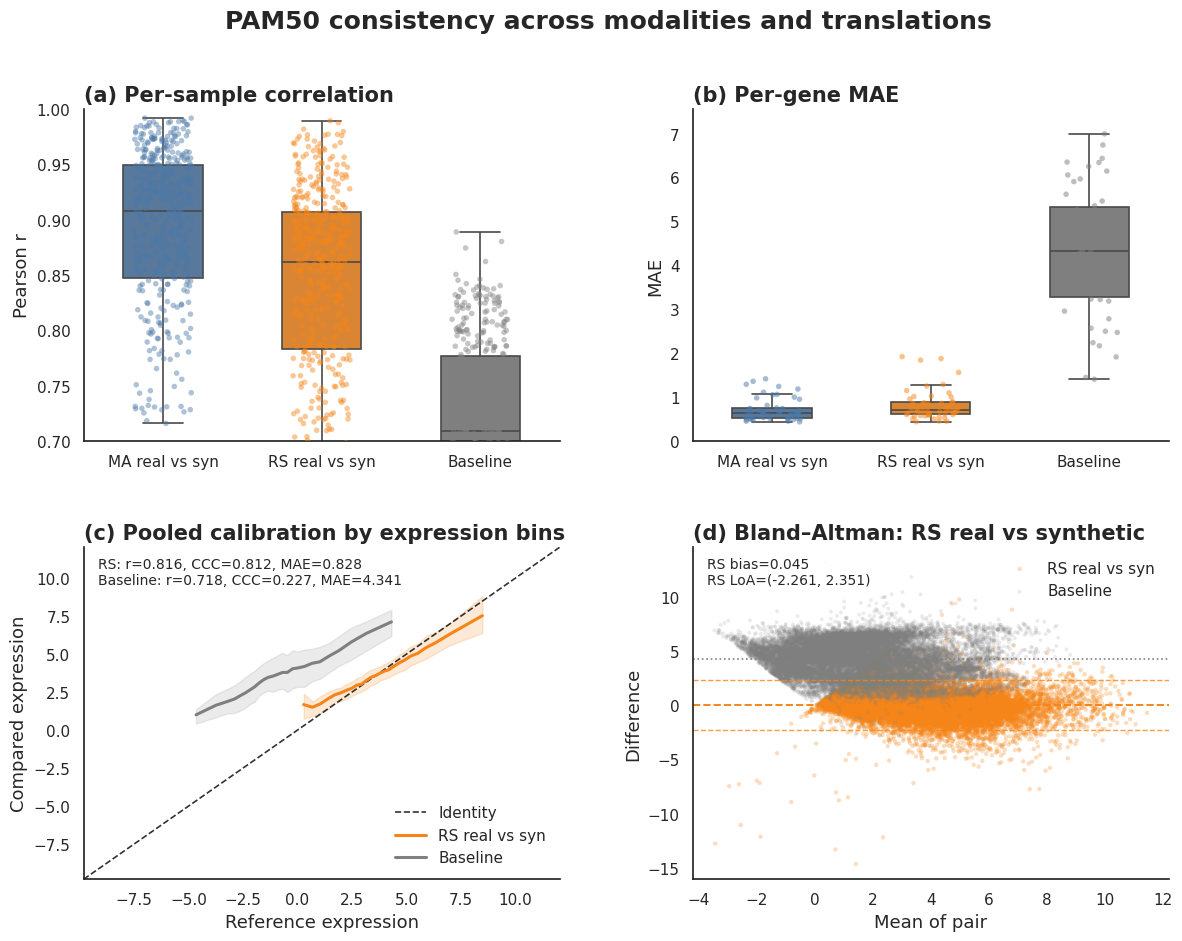

In [17]:
res = plot_pam50_consistency_2x2(
    df_ma_real_pam50, df_ma_fake_pam50,
    df_rs_real_pam50, df_rs_fake_pam50,
    save_path=None,
    overlay_baseline_in_ba=True
)